## 画图

In [77]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing import event_accumulator
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import FuncFormatter, FormatStrFormatter # 确保导入了 FormatStrFormatter

def plot_tensorboard_comparison(log_dirs, labels, baseline_dict=None, smoothing=0.0):
    tag_mapping = {
        'scalars/train_SR_mean': 'SR_mean',
        'scalars/train_SR':       'SR_mean',
        'train/avg_SR':          'SR_mean',
        'scalars/train_SR_std':  'SR_std',
        'SR_std':                'SR_std',
        'scalars/train_WFE':     'WFE',
        'WFE_val':               'WFE',
        'train/avg_WFE':         'WFE'
    }
    
    tags_to_scale = ['train/avg_SR', 'train/avg_WFE']
    target_metrics = ['SR_mean', 'SR_std', 'WFE']
    
    try:
        plt.style.use('ggplot')
    except:
        plt.style.use('default')

    formatter = FuncFormatter(lambda x, pos: f'{x/1000:.0f}k' if x >= 1000 else int(x))

    def smooth_curve(values, weight):
        if not values: return []
        last = values[0]
        smoothed = []
        for point in values:
            smoothed_val = last * weight + (1 - weight) * point
            smoothed.append(smoothed_val)
            last = smoothed_val
        return smoothed

    for target in target_metrics:
        plt.figure(figsize=(10, 6))
        
        for log_dir, run_label in zip(log_dirs, labels):
            # --- 修改部分：收集该路径下所有 event 文件的数据 ---
            all_steps = []
            all_values = []
            
            # 获取所有 tfevents 文件并排序（确保时间顺序）
            event_files = []
            for root, _, files in os.walk(log_dir):
                for file in files:
                    if "tfevents" in file:
                        event_files.append(os.path.join(root, file))
            event_files.sort() 

            for event_file in event_files:
                ea = event_accumulator.EventAccumulator(event_file, size_guidance={'scalars': 0})
                ea.Reload()
                available_tags = ea.Tags()['scalars']

                possible_source_tags = [k for k, v in tag_mapping.items() if v == target]
                actual_tag = next((t for t in possible_source_tags if t in available_tags), None)
                
                if actual_tag:
                    data = ea.Scalars(actual_tag)
                    scale = 500 if actual_tag in tags_to_scale else 1
                    all_steps.extend([d.step * scale for d in data])
                    all_values.extend([d.value for d in data])

            # 如果收集到了数据，则绘图
            if all_steps:
                # 按 step 排序，防止断点续传时日志顺序错乱导致的连线乱跳
                combined = sorted(zip(all_steps, all_values))
                steps, values = zip(*combined)
                
                if smoothing > 0:
                    values = smooth_curve(values, smoothing)
                
                plt.plot(steps, values, label=run_label, linewidth=2)

        # 绘制 Baseline 和 修饰
        if baseline_dict and target in baseline_dict:
            plt.axhline(y=baseline_dict[target], color='black', linestyle='--', label=f'Baseline ({baseline_dict[target]})', alpha=0.7)

        
        # 5. 图表修饰
        # plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
        plt.title(f'{target}', fontsize=16, fontweight='bold')
        plt.xlabel('Frame (Total Steps)', fontsize=12)
        plt.ylabel('Value', fontsize=12)
        plt.gca().xaxis.set_major_formatter(formatter)
        plt.legend(loc='best')
        plt.grid(True, linestyle=':', alpha=0.8)
        plt.tight_layout()
        plt.show()

# 调用示例同上

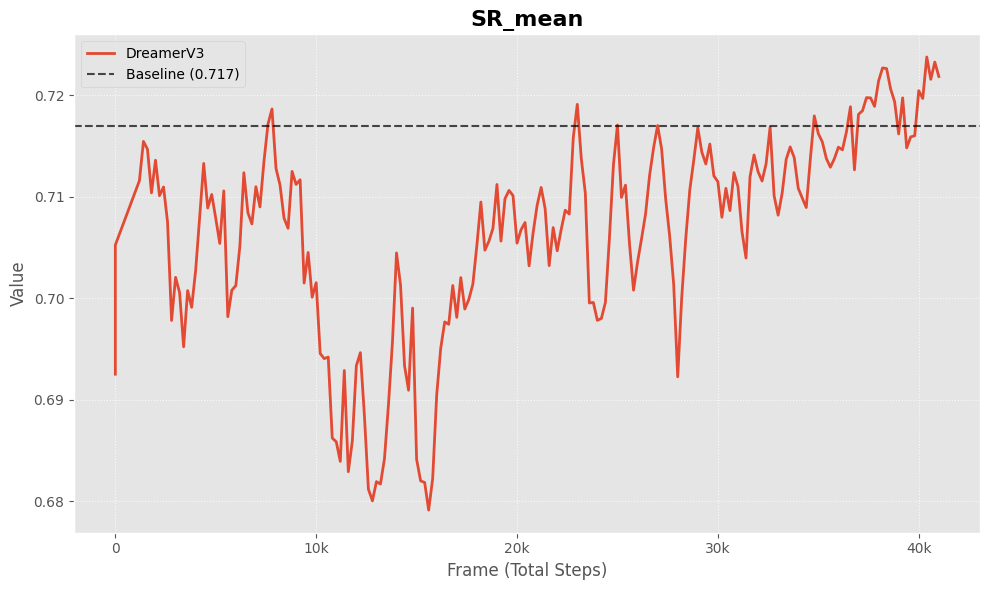

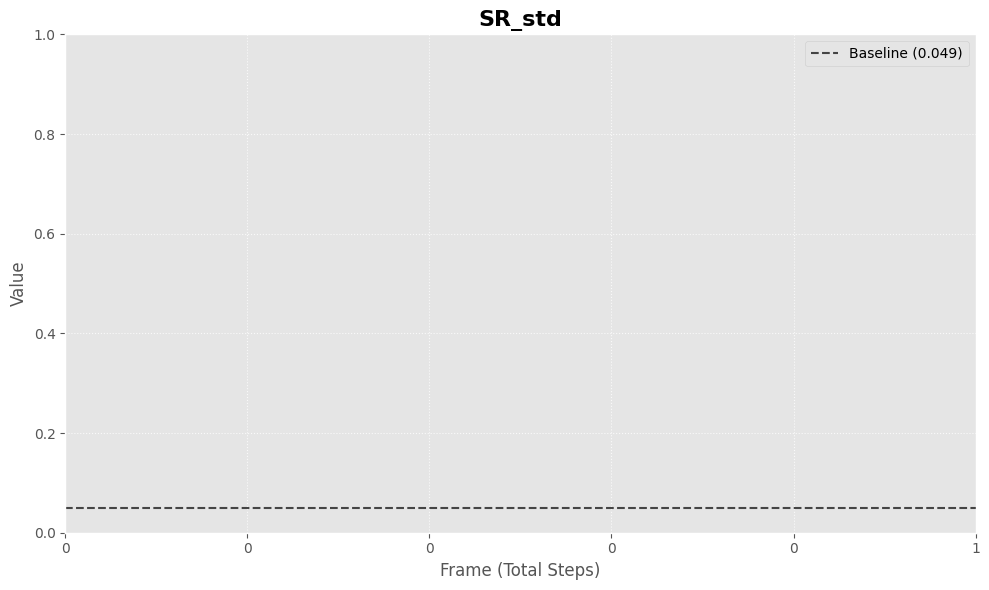

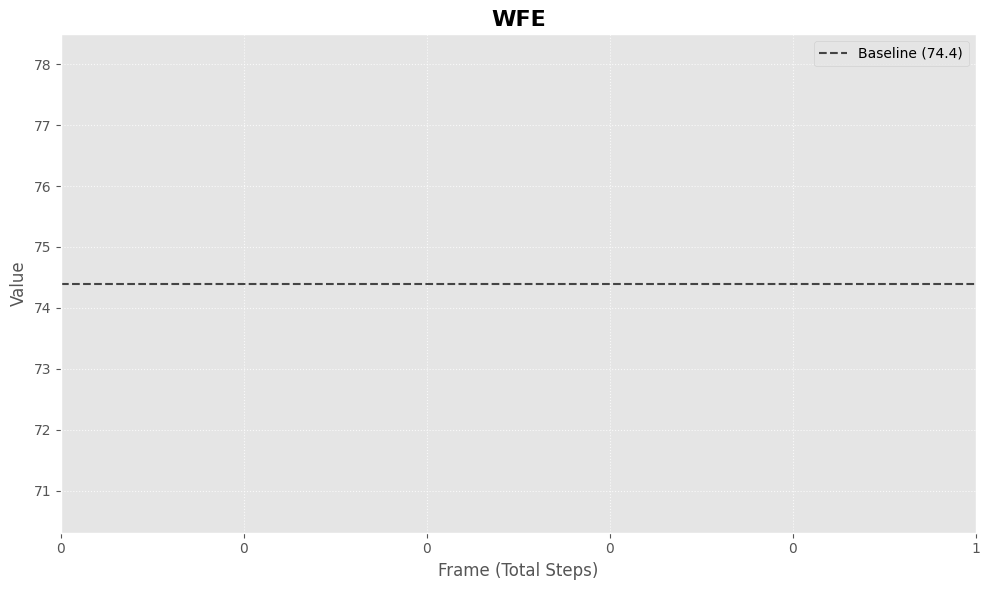

In [82]:

dreamer = "/DATACENTER5/jicheng.liu/SWJTU_OOPAO/SWJTU_OOPAO/tutorials/scao_system/myAoSystem/RL4AO/agent/dreamerv3/logdir/AO4_R2DISC_magnitude6_reward_test_mlp4_lossweight_explutil0"
# ppo = "/DATACENTER5/jicheng.liu/SWJTU_OOPAO/runs/1-1/ppo_mid_fusion_R2_episodes100_file2-2_20260114_164849/20260114_164849"
logdirs = [dreamer]
plot_tensorboard_comparison(
    log_dirs=logdirs,
    labels=['DreamerV3'],
    # SR_mean = 0.6951,SR_std = 0.0476,WFE = 83.55
    baseline_dict={'SR_mean': 0.717, 'SR_std': 0.049, 'WFE': 74.4},
    smoothing=0.6
)